# **A/B Testing & Regression Analysis for Landing Page Optimization**



---
Evaluating the impact of a redesigned landing page on conversion behavior using A/B testing and logistic regression


##**EXECUTIVE SUMMARY**



*   This project evaluates whether a redesigned landing page significantly improved user conversion compared to an existing version using A/B testing.

*   Statistical testing showed that the treatment landing page significantly outperformed the control group, improving conversion rate by 6.08 percentage points, representing a 51.18% relative uplift.

*   Logistic regression further confirmed that the treatment page remained the strongest predictor of conversion even after controlling for demographic, geographic, and behavioral factors.



## **1. Business Problem & Objective**

---

##**Business Problem**

  *The business introduced a redesigned landing page to improve customer conversion rates. An A/B experiment was conducted to compare the performance of the existing page (control) and redesigned page (treatment).*

##**Objective**

  *Determine whether the treatment landing page significantly improves conversion rate and engagement behavior.*

##**Success Criteria**

   *A statistically significant improvement at α = 0.05 with meaningful business uplift.*

##**Primary KPI**

   *Conversion Rate*

##**Secondary KPIs**

*Session Duration*
*Pages Visited*
*Purchase Amount*

##**2. Data Loading & Initial Inspection**



###
2.1 Import Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

###2.2 Load Dataset

In [4]:
df= pd.read_csv('AB Testing Data.csv')

###2.3 Dataset Shape

In [5]:
df.shape

(294478, 12)

### 2.4 Dataset Structure

In [6]:
df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted', 'age',
       'gender', 'location', 'session_duration', 'pages_visited',
       'device_type', 'purchase_amount'],
      dtype='object')

### 2.5 Dataset Preview

In [7]:
df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


### 2.6 Missing Value Analysis

In [48]:
df.isnull().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0
age,0
gender,0
location,0
session_duration,0
pages_visited,0


## **3. Experiment Validation & Randomization Check**

Before conducting A/B testing, experiment groups should be validated to ensure balanced exposure and unbiased randomization.

### 3.1 Group Distribution

In [84]:
group_distribution = (
    df.groupby('group')
    .agg(
        total_users=('user_id', 'count'),
        converted_users=('converted', 'sum')
    )
)

group_distribution

,total_users,converted_users
group,,
control,146926,17444
treatment,147552,26484


### 3.2 Device-Level Balance

In [92]:
pd.crosstab(
    df['group'],
    df['device_type']
)

device_type,Desktop,Mobile,Tablet
group,,,
control,88397,51177,7352
treatment,88295,51916,7341


### 3.3 Demographic & Geographic Randomization

In [85]:
pd.crosstab(
    df['group'],
    df['location']
)

location,Australia,Canada,Germany,India,Pakistan,UK,US
group,,,,,,,
control,7285,14603,14798,29378,14724,22127,44011
treatment,7302,14638,14679,29636,14876,22090,44331


In [86]:
df.groupby('group')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control,146926.0,31.885704,9.248324,18.0,25.0,31.0,38.0,65.0
treatment,147552.0,31.918395,9.251758,18.0,25.0,32.0,38.0,65.0


### 3.4 Randomization Insights



*   The experiment groups appear reasonably balanced across demographic and behavioral variables, suggesting the randomization process was effective.


## **4. Exploratory Data Analysis (EDA)**

### 4.1 Conversion Rate Analysis

*   Conversion rate is the primary metric used to evaluate treatment effectiveness.



In [59]:

ab_summary = (
    df.groupby('group')
      .agg(
          total_users=('converted', 'count'),
          converted_users=('converted', 'sum')
      )
)

# Calculate conversion rate
ab_summary['conversion_rate'] = (
    ab_summary['converted_users']
    / ab_summary['total_users']
)

ab_summary

,total_users,converted_users,conversion_rate
group,,,
control,146926,17444,0.118726
treatment,147552,26484,0.179489


In [60]:
# Conversion rates
p_control = ab_summary.loc[
    'control',
    'conversion_rate'
]

p_treatment = ab_summary.loc[
    'treatment',
    'conversion_rate'
]

print(
    "Control Conversion Rate:",
    round(p_control, 4)
)

print(
    "Treatment Conversion Rate:",
    round(p_treatment, 4)
)

Control Conversion Rate: 0.1187
Treatment Conversion Rate: 0.1795


### 4.2 Conversion Rate Visualization

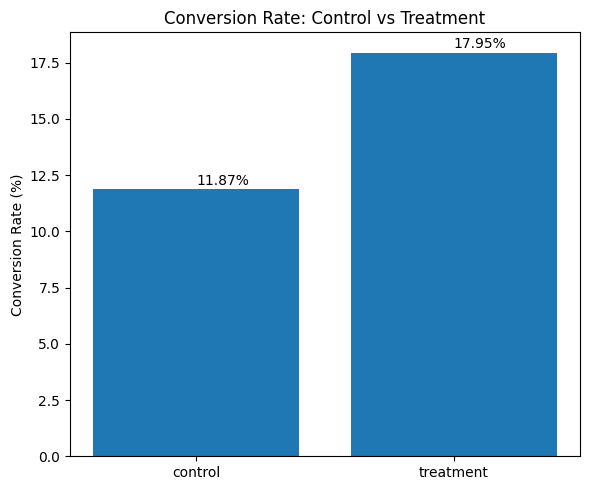

In [94]:
# Conversion rates Visualization
conversion_rates = (
    ab_summary['conversion_rate'] * 100
)

plt.figure(figsize=(6,5))

plt.bar(
    conversion_rates.index,
    conversion_rates.values
)

plt.title(
    'Conversion Rate: Control vs Treatment'
)

plt.ylabel('Conversion Rate (%)')

for i, value in enumerate(
    conversion_rates.values
):
    plt.text(
        i,
        value + 0.2,
        f'{value:.2f}%'
    )
plt.tight_layout()
plt.show()

### 4.3 Relative Uplift Analysis

In [61]:
# Relative uplift
relative_uplift = (
    (p_treatment - p_control)
    / p_control
) * 100

print(
    f"Relative Uplift: "
    f"{relative_uplift:.2f}%"
)

Relative Uplift: 51.18%


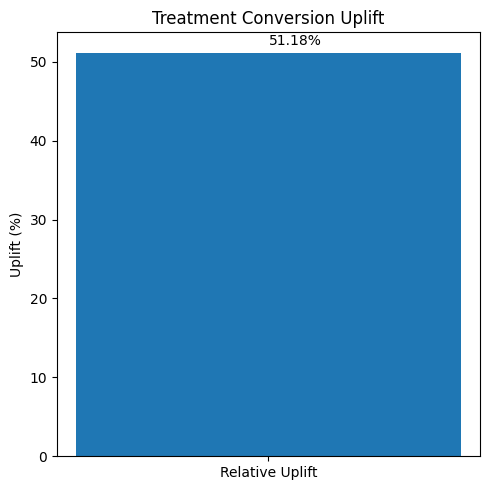

In [93]:
#Relative Uplift Visualisation
uplift_value = relative_uplift

plt.figure(figsize=(5,5))

plt.bar(
    ['Relative Uplift'],
    [uplift_value]
)

plt.title(
    'Treatment Conversion Uplift'
)

plt.ylabel('Uplift (%)')

plt.text(
    0,
    uplift_value + 1,
    f'{uplift_value:.2f}%'
)
plt.tight_layout()
plt.show()

### 4.4 Engagement Analysis

In [67]:
#Session Analysis
session_analysis = (
    df.groupby('group')['session_duration']
      .agg(
          avg_session_duration='mean',
          median_session_duration='median'
      )
)

session_analysis

,avg_session_duration,median_session_duration
group,,
control,5.003684,5.00
treatment,5.000594,4.98


In [68]:
#Page Analysis
pages_analysis = (
    df.groupby('group')['pages_visited']
      .agg(['mean', 'median'])
)

pages_analysis

,mean,median
group,,
control,4.015327,4.0
treatment,4.023754,4.0


In [69]:
#Purchase Analysis
purchase_analysis = (
    df.groupby('group')['purchase_amount']
      .agg(['mean', 'median', 'sum'])
)

purchase_analysis

,mean,median,sum
group,,,
control,4.452769,0.0,654227.55
treatment,6.763299,0.0,997938.36


### 4.5 Device-Level Conversion Analysis

In [71]:
#device conversion analysis
device_conversion = (
    df.groupby(['device_type', 'group'])
      .agg(
          total_users=('converted', 'count'),
          converted_users=('converted', 'sum')
      )
)

device_conversion['conversion_rate'] = (
    device_conversion['converted_users']
    / device_conversion['total_users']
) * 100

device_conversion.reset_index()

,device_type,group,total_users,converted_users,conversion_rate
0,Desktop,control,88397,10563,11.949501
1,Desktop,treatment,88295,15966,18.082564
2,Mobile,control,51177,6010,11.743557
3,Mobile,treatment,51916,9196,17.713229
4,Tablet,control,7352,871,11.847116
5,Tablet,treatment,7341,1322,18.008446


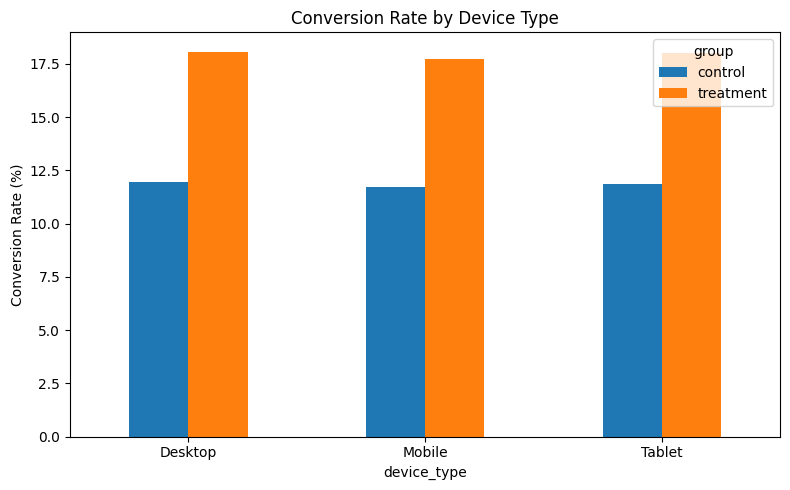

In [95]:
device_conversion = (
    df.groupby(
        ['device_type', 'group']
    )['converted']
    .mean()
    .reset_index()
)

device_conversion[
    'converted'
] *= 100

pivot_df = (
    device_conversion
    .pivot(
        index='device_type',
        columns='group',
        values='converted'
    )
)

pivot_df.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Conversion Rate by Device Type'
)

plt.ylabel(
    'Conversion Rate (%)'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.6 Key EDA Findings



####**Conversion Performance**

The treatment page improved conversion rate from 11.87% to 17.95%, showing stronger performance than the control page.

####**Relative Uplift**

The redesigned landing page increased conversions by 51.18%, indicating meaningful business improvement.

####**Business Impact**

If applied to one million monthly visitors, the treatment page could generate approximately 60,763 additional conversions.

####**Device Insights**

Mobile users showed slightly lower conversion performance, suggesting opportunities for mobile UX optimization.

####**Geographic Insights**

Conversion performance remained relatively consistent across locations, indicating the treatment effect worked broadly across regions.

####**Demographic Insights**

Gender had minimal impact on conversion. Older users showed slightly lower conversion tendency, though the effect was small.

####**Engagement Insights**

Session duration and pages visited showed weak influence on conversion, suggesting browsing behavior alone did not strongly drive purchases.

## **5. Statistical A/B Testing**



### 5.1 Hypothesis Formulation

**Null Hypothesis (H₀) : H0​:pT​≤pC**

The treatment page does not improve conversion rate.

**Alternative Hypothesis (Hₐ) : Ha​:pT​>pC​**

The treatment page improves conversion rate.

### 5.2 Two-Proportion Z-Test
  Performed to evaluate whether the observed difference in conversion rate between the treatment and control groups is statistically significant.

In [97]:
control = ab_summary.loc['control']
treatment = ab_summary.loc['treatment']

success_count = [
    treatment['converted_users'],
    control['converted_users']
]

sample_size = [
    treatment['total_users'],
    control['total_users']
]

z_statistic, p_value = proportions_ztest(
    count=success_count,
    nobs=sample_size,
    alternative='larger'
)

print("Z-statistic:", round(z_statistic, 4))
print(p_value)
print(f"P-value: {p_value:e}")
print("P-value:", round(p_value, 6))

Z-statistic: 46.2773
0.0
P-value: 0.000000e+00
P-value: 0.0


### 5.3 Statistical Decision

In [77]:
alpha = 0.05
if p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("The treatment significantly improved conversion rate.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("No statistically significant improvement was found.")

Reject the Null Hypothesis (H₀)
The treatment significantly improved conversion rate.


### 5.4 Manual Statistical Validation

In [31]:
import numpy as np

# Control group
n_control = 146926
x_control = 17444

# Treatment group
n_treatment = 147552
x_treatment = 26484

# Conversion rates
p_control = x_control / n_control
p_treatment = x_treatment / n_treatment

# Pooled proportion
p_pool = (
    (x_control + x_treatment)
    / (n_control + n_treatment)
)

# Standard error
se = np.sqrt(
    p_pool * (1 - p_pool) *
    ((1 / n_control) + (1 / n_treatment))
)

# Z-score
z_score = (
    p_treatment - p_control
) / se

print("Control Conversion Rate:", round(p_control, 4))
print("Treatment Conversion Rate:", round(p_treatment, 4))
print("Difference:", round(p_treatment - p_control, 4))
print("Standard Error:", round(se, 6))
print("Manual Z-score:", round(z_score, 4))

Control Conversion Rate: 0.1187
Treatment Conversion Rate: 0.1795
Difference: 0.0608
Standard Error: 0.001313
Manual Z-score: 46.2773


### 5.5 Confidence Interval Analysis



In [80]:
# Control group metrics
n_control = 146926
x_control = 17444

# Treatment group metrics
n_treatment = 147552
x_treatment = 26484

# Conversion rates
p_control = x_control / n_control
p_treatment = x_treatment / n_treatment

# Difference in conversion rate
difference = p_treatment - p_control

# Standard error of difference
se_difference = np.sqrt(
    (p_control * (1 - p_control) / n_control)
    +
    (p_treatment * (1 - p_treatment) / n_treatment)
)

# 95% confidence interval
z_critical = 1.96

margin_of_error = z_critical * se_difference

lower_bound = difference - margin_of_error
upper_bound = difference + margin_of_error

print("Observed Difference:", round(difference, 4))
print("95% Confidence Interval:")
print(f"Lower Bound: {lower_bound:.4f}")
print(f"Upper Bound: {upper_bound:.4f}")

Observed Difference: 0.0608
95% Confidence Interval:
Lower Bound: 0.0582
Upper Bound: 0.0633


In [82]:
# Confidence interval using confint_proportions_2indep
lower_ci, upper_ci = (
    confint_proportions_2indep(
        count1=26484,
        nobs1=147552,
        count2=17444,
        nobs2=146926,
        compare='diff',
        alpha=0.05
    )
)

print(
    f"95% Confidence Interval: "
    f"({lower_ci:.4f}, {upper_ci:.4f})"
)

95% Confidence Interval: (0.0582, 0.0633)


### 5.6 Confidence Interval Visualization

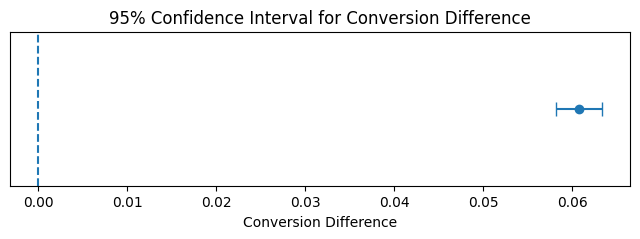

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,2))

plt.errorbar(
    x=difference,
    y=0,
    xerr=[
        [difference - lower_bound],
        [upper_bound - difference]
    ],
    fmt='o',
    capsize=5
)

plt.axvline(
    0,
    linestyle='--'
)

plt.title(
    '95% Confidence Interval '
    'for Conversion Difference'
)

plt.xlabel(
    'Conversion Difference'
)

plt.yticks([])

plt.show()

In [78]:
monthly_visitors = 1_000_000

expected_extra_conversions = (
    monthly_visitors *
    difference
)

print(
    f"Estimated additional conversions "
    f"per month: "
    f"{expected_extra_conversions:,.0f}"
)

Estimated additional conversions per month: 60,763



### 5.7 Statistical Interpretation




####**Hypothesis Testing**

The A/B test confirmed that the treatment page significantly improved conversion performance (p < 0.001).

####**Confidence Interval**

The estimated conversion uplift likely falls between 5.82% and 6.33%, confirming a consistently positive treatment effect.

####**Practical Significance**

The improvement was not only statistically significant but also large enough to create meaningful business impact.


## 6. Logistic Regression Analysis


### 6.1 Why Logistic Regression?

Used to validate whether the treatment effect remains significant after controlling for user characteristics because conversion is a binary outcome.

### 6.2 Data Validation

In [42]:
# Check unique gender values
df['gender'].value_counts(
    dropna=False
)

,count
gender,
Male,144708
Female,143785
Other,5985


### 6.3 Data Preparation

In [43]:
model_df = df.copy()


model_df['treatment'] = (
    model_df['group']
    .map({
        'control': 0,
        'treatment': 1
    })
)

model_df = pd.get_dummies(
    model_df,
    columns=[
        'gender',
        'device_type',
        'location'
    ],
    drop_first=True
)

model_df = model_df.dropna()

print(
    "Remaining rows:",
    len(model_df)
)

model_df.head()

Remaining rows: 294478


,user_id,timestamp,group,landing_page,converted,age,session_duration,pages_visited,purchase_amount,treatment,gender_Male,gender_Other,device_type_Mobile,device_type_Tablet,location_Canada,location_Germany,location_India,location_Pakistan,location_UK,location_US
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,3.69,4,0.0,0,True,False,True,False,False,False,False,True,False,False
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,1.29,3,0.0,1,False,False,False,False,False,False,False,False,True,False
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,3.72,5,0.0,1,True,False,False,False,False,False,False,False,False,True
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,7.76,2,0.0,1,False,False,True,False,False,False,True,False,False,False
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,6.78,6,0.0,0,True,False,True,False,False,False,False,False,False,False


### 6.4 Feature Selection

In [44]:
features = [
    'treatment',
    'age',
    'session_duration',
    'pages_visited'
]

dummy_cols = [
    col for col in model_df.columns
    if (
        'gender_' in col
        or 'device_type_' in col
        or 'location_' in col
    )
]

features.extend(dummy_cols)

X = model_df[features]

y = model_df['converted']

print(X.shape)
print(y.shape)

(294478, 14)
(294478,)


### 6.5 Model Training

In [45]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(X, y)

print(
    "Model training completed."
)

Model training completed.


###6.6 Coefficient Analysis

In [46]:
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='coefficient',
    ascending=False
)

coefficients

,feature,coefficient
0,treatment,0.485608
5,gender_Other,0.072663
4,gender_Male,0.013443
8,location_Canada,0.008553
10,location_India,0.004173
3,pages_visited,0.002136
2,session_duration,-0.000506
1,age,-0.001461
12,location_UK,-0.002129
13,location_US,-0.005488


### 6.7 Feature Importance Visualization

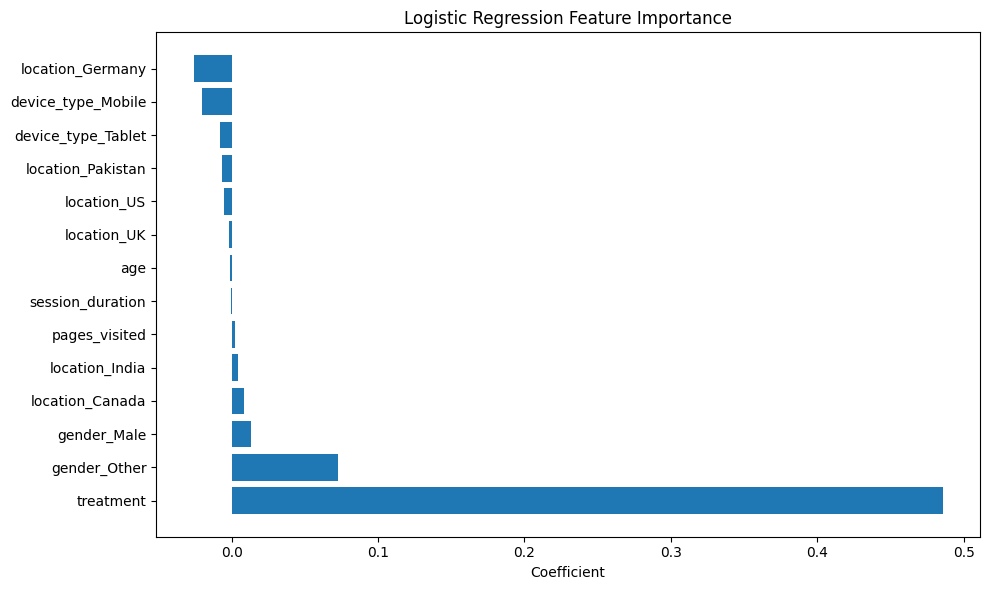

In [98]:
coef_df = coefficients.copy()

plt.figure(figsize=(10,6))

plt.barh(
    coef_df['feature'],
    coef_df['coefficient']
)

plt.title(
    'Logistic Regression '
    'Feature Importance'
)

plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

### 6.8 Statistical Significance of Logistic Regression

In [89]:
import statsmodels.api as sm

X_sm = X.astype(float)

X_sm = sm.add_constant(X_sm)

y_sm = y.astype(int)

logit_model = sm.Logit(
    y_sm,
    X_sm
)

result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.417586
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               294478
Model:                          Logit   Df Residuals:                   294463
Method:                           MLE   Df Model:                           14
Date:                Tue, 26 May 2026   Pseudo R-squ.:                0.008748
Time:                        14:55:36   Log-Likelihood:            -1.2297e+05
converged:                       True   LL-Null:                   -1.2406e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.9630      0.035    -55.836      0.000      -2.032      -1.894
treat

In [91]:
significant_variables = pd.DataFrame({
    'feature': result.params.index,
    'coefficient': result.params.values,
    'p_value': result.pvalues.values
})

significant_variables = (
    significant_variables[
        significant_variables[
            'p_value'
        ] < 0.05
    ]
)

significant_variables

,feature,coefficient,p_value
0,const,-1.962981,0.000000
1,treatment,0.484847,0.000000
2,age,-0.001408,0.012249
7,device_type_Mobile,-0.022888,0.038560


### 6.9 Odds Ratio

In [90]:
import numpy as np

odds_ratio = np.exp(
    result.params
)

odds_ratio_df = pd.DataFrame({
    'feature': odds_ratio.index,
    'odds_ratio': odds_ratio.values
})


odds_ratio_df = (
    odds_ratio_df
    .sort_values(
        by='odds_ratio',
        ascending=False
    )
)

odds_ratio_df

,feature,odds_ratio
1,treatment,1.623926
6,gender_Other,1.034723
5,gender_Male,1.011020
9,location_Canada,1.010440
11,location_India,1.006278
4,pages_visited,1.002124
3,session_duration,0.999644
13,location_UK,0.999566
2,age,0.998593
14,location_US,0.996654


### 6.10 Regression Insights

*  Logistic regression was performed to evaluate whether the treatment landing page remained influential after controlling for demographic, behavioral, and geographic variables.

*  The treatment variable remained highly statistically significant (p < 0.001) and demonstrated the strongest positive relationship with conversion.

*  Odds ratio analysis showed that users exposed to the treatment landing page were approximately 1.62× more likely to convert than users exposed to the control version while holding other variables constant.

*  Age showed a statistically significant but practically small negative relationship with conversion probability.

*  Mobile users demonstrated slightly lower conversion likelihood, suggesting potential opportunities for mobile experience optimization.

*  Most demographic and geographic variables were not statistically significant, indicating that conversion improvement was primarily driven by the treatment experience rather than user composition differences.

##7. Business Recommendations



**Recommendation 1: Roll Out the Treatment Landing Page**

* Since the treatment page demonstrated both statistical significance and
practical significance, the redesigned landing page should be considered for broader rollout.

**Recommendation 2: Optimize Mobile Experience**

* Mobile users showed slightly lower conversion likelihood. Additional UX testing focused on mobile layouts, navigation, and page responsiveness may further improve performance.

**Recommendation 3: Continue Controlled Experimentation**

* Future A/B tests should evaluate additional landing page elements such as CTA placement, personalization, visual hierarchy, and product presentation to further optimize conversion performance.

**Recommendation 4: Monitor Post-Implementation Performance**

* After rollout, the business should continue monitoring conversion rate, bounce rate, retention, and revenue metrics to validate long-term effectiveness.


##8. Conclusion

- Treatment page improved conversion rate by **51.18%**
- A/B testing confirmed statistical significance (**p < 0.001**)
- Confidence interval estimated uplift between **5.82% and 6.33%**
- Treatment users were **1.62× more likely to convert**
- Mobile users showed slightly lower conversion tendency.